In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# data loading and RUL computation

In [2]:
from src.data.loading import load_train, load_test, load_rul, load_readme, sensor_columns, operation_columns
from src.features.build_features import add_rul_target
from src.config import DEFAULT_RUL_CAP

def load_readme(data_dir):
    path = Path(data_dir) / "README.txt"   # or README.md
    if not path.exists():
        return ""
    return path.read_text(encoding="utf-8", errors="ignore")



# load FD001
FD--1 is the cleanest starting point because it has one operating condition and one fault mode, use it before moving to FD002-FD004,


In [3]:
df = load_train(DATA_DIR, dataset="FD001")
print(df.shape)
df.head()

(20631, 26)


,unit,cycle,op_1,op_2,op_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [4]:

print("Operation columns:", operation_columns(df))
print("Sensor columns:", sensor_columns(df))
df.describe().T.head(12)


Operation columns: ['op_1', 'op_2', 'op_3']
Sensor columns: ['s_1', 's_2', 's_3', 's_4', 's_5', 's_6', 's_7', 's_8', 's_9', 's_10', 's_11', 's_12', 's_13', 's_14', 's_15', 's_16', 's_17', 's_18', 's_19', 's_20', 's_21']


,count,mean,std,min,25%,50%,75%,max
unit,20631.0,51.506568,2.922763e+01,1.0000,26.0000,52.00,77.0000,100.0000
cycle,20631.0,108.807862,6.888099e+01,1.0000,52.0000,104.00,156.0000,362.0000
op_1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.00,0.0015,0.0087
op_2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.00,0.0003,0.0006
op_3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.00,100.0000,100.0000
s_1,20631.0,518.670000,0.000000e+00,518.6700,518.6700,518.67,518.6700,518.6700
s_2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.64,643.0000,644.5300
s_3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.10,1594.3800,1616.9100
s_4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.04,1414.5550,1441.4900
s_5,20631.0,14.620000,1.776400e-15,14.6200,14.6200,14.62,14.6200,14.6200


## Add RUL target

In the training set, each engine runs until failure. So for each engine:

`RUL = final_cycle_of_that_engine - current_cycle`

We cap RUL at 140 because very early cycles can dominate training with very large target values.


In [5]:
df = add_rul_target(df, cap=DEFAULT_RUL_CAP)
df[["unit", "cycle", "max_cycle", "RUL"]].head()


,unit,cycle,max_cycle,RUL
0,1,1,192,140
1,1,2,192,140
2,1,3,192,140
3,1,4,192,140
4,1,5,192,140


In [6]:
engine_summary = df.groupby("unit").agg(
    min_cycle=("cycle", "min"),
    max_cycle=("cycle", "max"),
    rows=("cycle", "size"),
    max_rul=("RUL", "max"),
    min_rul=("RUL", "min"),
).reset_index()
engine_summary.head()


,unit,min_cycle,max_cycle,rows,max_rul,min_rul
0,1,1,192,192,140,0
1,2,1,287,287,140,0
2,3,1,179,179,140,0
3,4,1,189,189,140,0
4,5,1,269,269,140,0


## Quick EDA: which sensors change?

Low-variance sensors often add little information. This does **not** mean we delete them blindly, but it helps us choose sensors for first experiments.


In [7]:
sensor_std = df[sensor_columns(df)].std().sort_values()
sensor_std



s_1     0.000000e+00
s_10    0.000000e+00
s_19    0.000000e+00
s_18    0.000000e+00
s_16    1.387812e-17
s_5     1.776400e-15
s_6     1.388985e-03
s_15    3.750504e-02
s_8     7.098548e-02
s_13    7.191892e-02
s_21    1.082509e-01
s_20    1.807464e-01
s_11    2.670874e-01
s_2     5.000533e-01
s_12    7.375534e-01
s_7     8.850923e-01
s_17    1.548763e+00
s_3     6.131150e+00
s_4     9.000605e+00
s_14    1.907618e+01
s_9     2.208288e+01
dtype: float64

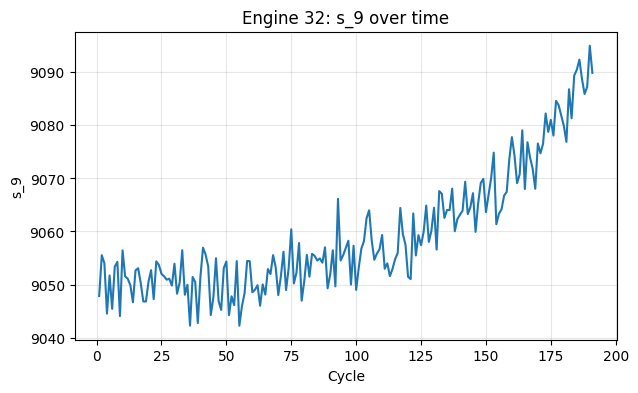

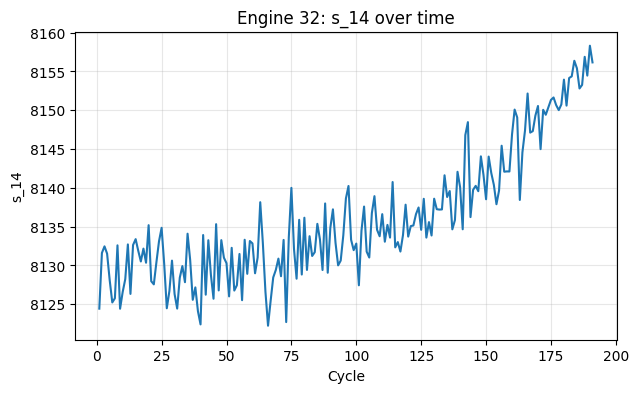

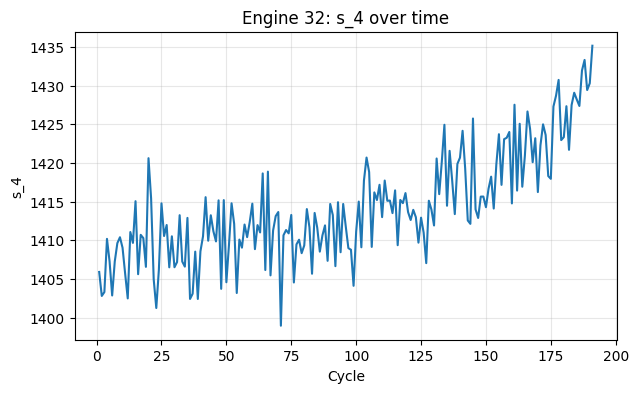

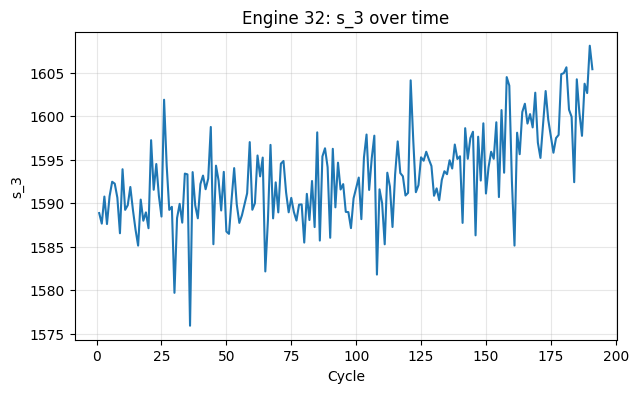

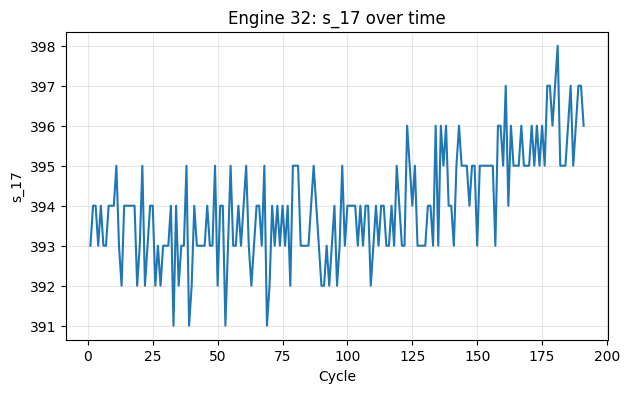

In [8]:
selected_engine = 32
candidate_sensors = ["s_9", "s_14", "s_4", "s_3", "s_17"]
engine_df = df[df["unit"] == selected_engine]

for sensor in candidate_sensors:
    plt.figure(figsize=(7, 4))
    plt.plot(engine_df["cycle"], engine_df[sensor])
    plt.xlabel("Cycle")
    plt.ylabel(sensor)
    plt.title(f"Engine {selected_engine}: {sensor} over time")
    plt.grid(alpha=0.3)
    plt.show()


## Save prepared FD001 train data

Later notebooks can reload from raw data, but this CSV is useful for quick inspection.


In [9]:
df.to_csv(PROCESSED_DIR / "fd001_train_with_rul.csv", index=False)
print("Saved:", PROCESSED_DIR / "fd001_train_with_rul.csv")



Saved: C:\Users\Hp\OneDrive\Desktop\vehicle-predictive-maintenance\data\processed\fd001_train_with_rul.csv
